In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Complete Case Analysis

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
os.chdir(os.environ.get("DATASET_PATH"))

In [3]:
df = pd.read_csv("titanic_toy.csv")
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [4]:
# missing values
df.isnull().sum().sum()

np.int64(222)

In [5]:
df.info()   # age and fare column has missing values

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [ ]:
# check how much data is missing
df.isnull().mean()*100   # age has around 20 % missing values and fare has around 5%

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [6]:
# fill missing value
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy='mean')  # by default mean 
si

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [7]:
filled_cols = si.fit_transform(df[['Age','Fare']])
filled_cols = pd.DataFrame(filled_cols,columns=['NewAge','NewFare'])
filled_cols

,NewAge,NewFare
0,22.000000,7.250000
1,38.000000,71.283300
2,26.000000,7.925000
3,35.000000,53.100000
4,35.000000,8.050000
...,...,...
886,27.000000,13.000000
887,19.000000,30.000000
888,29.699118,23.450000
889,26.000000,32.279338


In [8]:
new_df = pd.concat([df,filled_cols], axis = 1).drop(columns=['Age','Fare'])
new_df.head()

,Family,Survived,NewAge,NewFare
0,1,0,22.0,7.2500
1,1,1,38.0,71.2833
2,0,1,26.0,7.9250
3,1,1,35.0,53.1000
4,0,0,35.0,8.0500


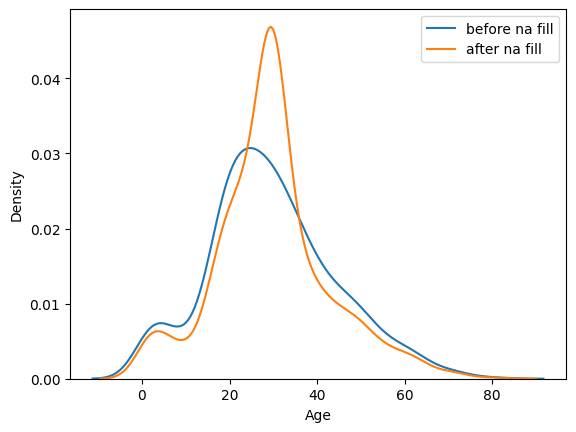

the distribution becomes peaked


In [9]:
# plot graphs to compare 
sns.kdeplot(data=df, x='Age', label = 'before na fill')
sns.kdeplot(data=new_df, x='NewAge', label='after na fill')
plt.legend()
plt.show()
print("the distribution becomes peaked")

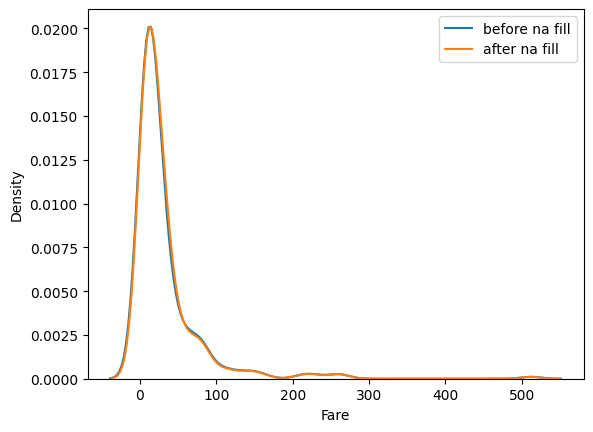

the distribution is almost same


In [13]:
# plot graphs to compare Fare
sns.kdeplot(data=df, x='Fare', label = 'before na fill')
sns.kdeplot(data=new_df, x='NewFare', label='after na fill')
plt.legend()
plt.show()
print("the distribution is almost same")

In [14]:
new_df.NewFare.isnull().sum()

np.int64(0)